**Cell 1: ติดตั้งไลบรารีที่จำเป็น**

In [ ]:
# 1. ติดตั้งไลบรารีที่จำเป็น (รันเซลล์นี้ก่อนถ้ายังไม่ได้ติดตั้ง)
# ติดตั้ง xee (สำหรับเชื่อม Earth Engine กับ xarray) และ geemap
!pip install -q xee geemap xarray shapely matplotlib

import ee
import geemap
import xarray as xr
import matplotlib.pyplot as plt
import shapely
from xee import helpers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.3 MB/s eta 0:00:00


**Cell 2: ยืนยันตัวตน**

In [ ]:
# ยืนยันตัวตน GEE (เปลี่ยน 'your-project-id' เป็นชื่อโปรเจกต์ของคุณ)
ee.Authenticate()
ee.Initialize(project='ee-end-to-end-gee')

**Cell 3: กำหนดพื้นที่ศึกษาและหน้ากากพื้นที่เกษตร**

กำลังดึงข้อมูล CWSI เข้าสู่ Xarray (อาจใช้เวลาสักครู่)...


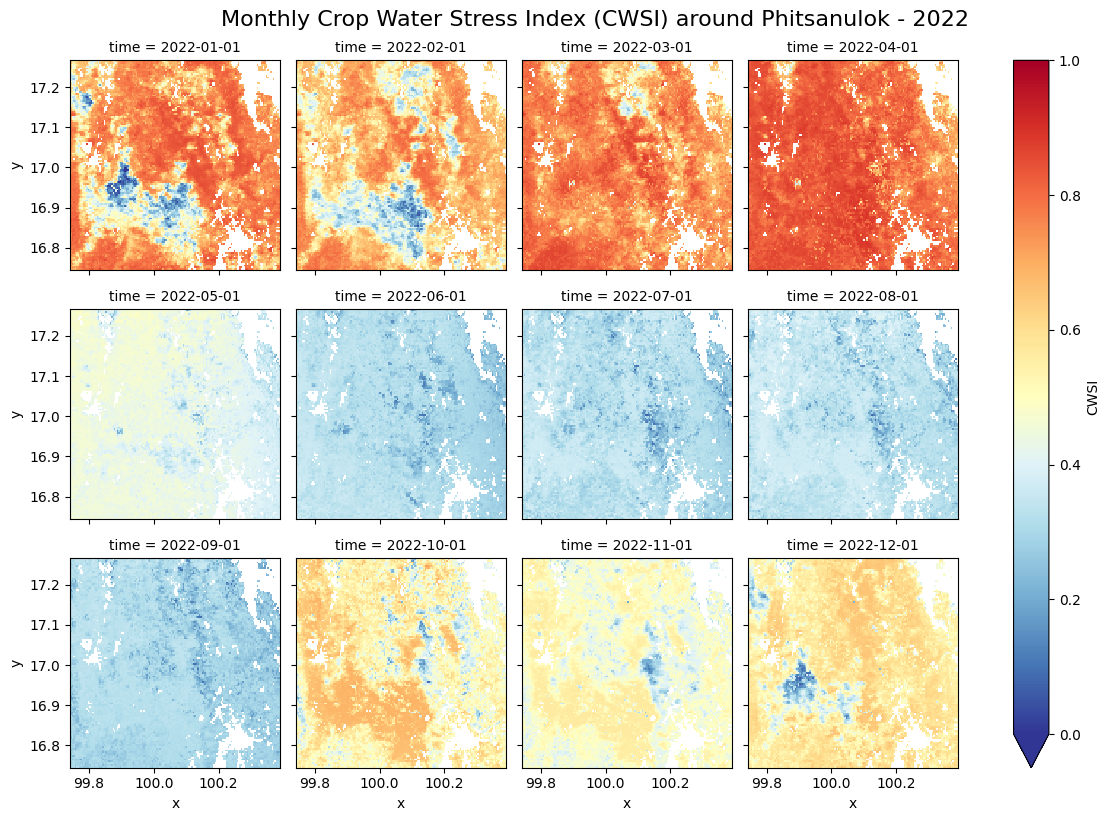

In [ ]:
# ==========================================
# 2. กำหนดพื้นที่ศึกษาและหน้ากากพื้นที่เกษตร
# ==========================================

# พิกัดมุมซ้ายล่าง และ มุมขวาบน ที่คุณกำหนด
min_lon, min_lat = 99.7447601905834, 16.748432178941215
max_lon, max_lat = 100.38929006606298, 17.266023831183105

# สร้างกรอบ Bounding Box
roi_ee = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
aoi_shapely = shapely.geometry.box(min_lon, min_lat, max_lon, max_lat)

# สร้างหน้ากากพื้นที่เกษตร (Crop Mask) จาก MODIS Land Cover (Class 12 = Croplands)
lc = ee.ImageCollection("MODIS/061/MCD12Q1").select('LC_Type1').mode()
crop_mask = lc.eq(12)

# ==========================================
# 3. สร้างฟังก์ชันคำนวณ CWSI รายเดือน (ปี 2022)
# ==========================================
year = 2022
months = ee.List.sequence(1, 12)

def calculate_cwsi(m):
    start = ee.Date.fromYMD(year, m, 1)
    end = start.advance(1, 'month')

    # ใช้ชุดข้อมูล MOD16A2GF (Gap-Filled) เพื่อลดปัญหาข้อมูลแหว่งจากเมฆ
    modis_et = ee.ImageCollection("MODIS/061/MOD16A2GF") \
        .filterDate(start, end) \
        .filterBounds(roi_ee) \
        .mean()

    # ดึงค่า ET และ PET (คูณ 0.1 เพื่อปรับสเกลตามมาตรฐานข้อมูล)
    et = modis_et.select('ET').multiply(0.1)
    pet = modis_et.select('PET').multiply(0.1)

    # คำนวณ CWSI = 1 - (ET / PET)
    # หมายเหตุ: .where() ใช้ป้องกัน Error กรณีที่ PET มีค่าเป็น 0 (หารด้วย 0)
    pet_safe = pet.where(pet.eq(0), 0.001)

    cwsi = ee.Image().expression(
        '1.0 - (et / pet)', {
            'et': et,
            'pet': pet_safe
        }
    ).rename('CWSI')

    # ใส่หน้ากากพืชเกษตร และประทับเวลาสำหรับการพล็อต
    return cwsi.updateMask(crop_mask) \
        .set('system:time_start', start.millis())

# วนลูปคำนวณสร้างเป็น ImageCollection
monthly_cwsi = ee.ImageCollection.fromImages(months.map(calculate_cwsi))

# ==========================================
# 4. ดึงข้อมูลเข้าสู่ Xarray และพล็อตกราฟ 12 เดือน
# ==========================================
print("กำลังดึงข้อมูล CWSI เข้าสู่ Xarray (อาจใช้เวลาสักครู่)...")

# ตั้งค่า Grid ตามมาตรฐาน xee v0.1.0+ (ความละเอียด ~500 เมตร)
grid_params = helpers.fit_geometry(
    geometry=aoi_shapely,
    grid_crs='EPSG:4326',
    grid_scale=(0.0045, -0.0045)
)

# ดึงข้อมูลมาเป็น Xarray Dataset
ds = xr.open_dataset(
    monthly_cwsi,
    engine='ee',
    **grid_params
)

# พล็อตภาพแบบ FacetGrid 12 ช่อง
# ใช้โทนสี 'RdYlBu_r' (ไล่จาก น้ำเงิน -> เหลือง -> แดง)
ds.CWSI.plot(
    x='x', y='y',
    col='time', col_wrap=4,
    cmap='RdYlBu_r',
    vmin=0.0, vmax=1.0,  # สเกลของ CWSI จะอยู่ระหว่าง 0 ถึง 1 เสมอ
    figsize=(12, 8)
)

plt.suptitle(f'Monthly Crop Water Stress Index (CWSI) around Phitsanulok - {year}', y=1.02, fontsize=16)
plt.show()

# ==========================================
# 5. [เพิ่มใหม่] คำสั่ง Export ไฟล์ GeoTIFF ลง Google Drive
# ==========================================
# print("กำลังส่งคำสั่ง Export ภาพทั้ง 12 เดือนไปยัง Google Drive...")

# for m in range(1, 13):
#     # ดึงภาพของแต่ละเดือนออกมา
#     img_export = monthly_cwsi.filter(ee.Filter.eq('month', m)).first()

#     # สร้าง Task สำหรับดาวน์โหลด
#     task = ee.batch.Export.image.toDrive(
#         image=img_export,
#         description=f'CWSI_Phitsanulok_2022_{m:02d}', # ชื่อไฟล์ (เช่น CWSI_Phitsanulok_2022_01)
#         folder='GEE_CWSI_Exports',                  # ชื่อโฟลเดอร์ที่จะสร้างใหม่ใน Drive
#         region=roi_ee,
#         scale=500,                                   # ความละเอียด 500 เมตร (ตาม MODIS)
#         crs='EPSG:4326',
#         maxPixels=1e10
#     )
#     task.start() # สั่งเริ่มทำงาน

# print("✅ ส่งคำสั่งสำเร็จ! กรุณารอประมาณ 5-10 นาที ไฟล์ GeoTIFF ทั้ง 12 ไฟล์จะทยอยเข้าไปอยู่ในโฟลเดอร์ 'GEE_CWSI_Exports' ใน Google Drive ของคุณครับ")



จากกราฟ CWSI (Crop Water Stress Index) ตลอดปี 2022 ที่บริเวณรอบๆ พิษณุโลก แผนที่ชุดนี้เล่าเรื่องราวสถานการณ์น้ำและการทำเกษตรในพื้นที่ได้อย่างชัดเจน เราสามารถแปลผลข้อมูลเชิงพื้นที่ (Spatial Analysis) จากภาพนี้ได้ดังนี้:

**1. วิกฤตหน้าแล้ง (มกราคม - เมษายน)**
สีแดงเถือก (CWSI เข้าใกล้ 1.0): ในช่วง 4 เดือนแรกของปี พื้นที่เกษตรส่วนใหญ่ตกอยู่ในสภาวะ "เครียดน้ำอย่างรุนแรง" พืชมีความต้องการน้ำสูงมาก (PET สูง) แต่น้ำในดินมีไม่พอให้คาย (ET ต่ำ)

จุดสังเกตที่น่าสนใจในเดือนกุมภาพันธ์: จะเห็นว่ามีหย่อม สีฟ้า/น้ำเงิน ปรากฏขึ้นมาตรงมุมซ้ายล่างและกระจายอยู่ตรงกลาง นี่คือหลักฐานเชิงประจักษ์ของการ "ให้น้ำชลประทาน" หรืออาจจะมีฝนหลงฤดูตกลงมาเฉพาะจุดครับ พื้นที่ตรงนั้นพืชได้รับน้ำจนชุ่มฉ่ำ ท่ามกลางพื้นที่รอบนอกที่แห้งแล้ง

**2. ฤดูฝนและอิทธิพลลานีญา (พฤษภาคม - กันยายน)**
การเปลี่ยนผ่านสี (Transition): เดือนพฤษภาคมเริ่มเห็นการเปลี่ยนจากสีส้มเป็นสีเหลืองอ่อนและขาว บ่งบอกถึงฝนเริ่มทิ้งตัวลงมา

สีฟ้าชุ่มฉ่ำ (CWSI เข้าใกล้ 0.0): ตั้งแต่เดือนมิถุนายนถึงกันยายน แผนที่กลายเป็นสีฟ้าเกือบทั้งหมด พืชไม่เครียดเลย ได้รับน้ำอย่างเต็มอิ่ม ซึ่งสอดคล้องกับสภาพอากาศปี 2022 ที่ฝนตกชุกและมีน้ำหลากในหลายพื้นที่ของภาคเหนือตอนล่างครับ

**3. ช่วงปลายฝนต้นหนาว (ตุลาคม - ธันวาคม)**
แผนที่เริ่มกลับมามีสีเหลืองและส้มอีกครั้ง เป็นสัญญาณของการสิ้นสุดฤดูฝน ดินเริ่มแห้งลง ซึ่งมักจะตรงกับช่วงเวลาเก็บเกี่ยวข้าว หรือการเตรียมดินสำหรับรอบการผลิตถัดไป

**ข้อสังเกตเพิ่มเติม:** รอยแหว่งสีขาวๆ ที่กระจายอยู่ทั่วแผนที่ คือการทำงานของ Crop Mask ที่เราเขียนกรองเอาพื้นที่เมือง ถนน แม่น้ำ และป่าไม้ออกไป ทำให้การวิเคราะห์ของเราโฟกัสเฉพาะพื้นที่เพาะปลูกจริงๆ

ข้อมูลชุดนี้มีประโยชน์มากสำหรับการบริหารจัดการน้ำเชิงพื้นที่ครับ หากเรานำภาพ Raster ชุดนี้ไปซ้อนทับกับแผนที่โครงข่ายคลองส่งน้ำ หรือขอบเขตแปลงเกษตรใน QGIS เราจะรู้ได้ทันทีเลยว่าพื้นที่ไหนอยู่ปลายคลองแล้วน้ำไปไม่ถึงจนพืชเกิดความเครียดสะสม
